# Building sector archetype model tutorial

This notebook shows how to build and analyse a building-sector model from:

- an **archetype table**: one row per possible building archetype
- a **constraints workbook**: statistical targets and shares that the model should reproduce
- `model.py`: the optimization wrapper around PuLP

The main goal is to create plausible synthetic building-sector compositions and analyse their resulting properties, for example:

- total net floor area (NFA)
- useful/final energy demand
- CO₂ emissions
- distribution by building use, age class, size class, building quality, geometry, and energy supply

The notebook is intended for student work. You should normally edit the Excel constraints, not `model.py`.

## Notebook outline

1. Load packages, `model.py`, archetypes, and constraints.
2. Inspect the archetype table.
3. Inspect and validate the constraints table.
4. Convert Excel rows into model constraints.
5. Solve the optimization model.
6. Inspect slacks and constraint deviations.
7. Analyse the resulting building sector.
8. Plot distributions by categories.
9. Calculate weighted totals such as energy use and emissions.
10. Compare different model variants.
11. Optional: add share constraints.
12. Export results for reports.

## 1. Setup

`model.py` contains the actual model. The important classes are:

- `BuildingSector`: container for archetypes, constraints, PuLP model, solving, and result extraction
- `Constraint`: one weighted constraint, either absolute or share-based
- `is_empty`: helper for empty Excel cells

The current `model.py` uses one decision variable per archetype $i$:

$
NFA_i \geq 0
$

This variable means: **how much net floor area of archetype `i` occurs in the modeled building sector**.

In [1]:
import sys
from pathlib import Path
import inspect

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional: useful during development if model.py changes
try:
    ip = get_ipython()
    ip.run_line_magic("load_ext", "autoreload")
    ip.run_line_magic("autoreload", "2")
except Exception:
    pass

# Make imports robust for both:
# - model.py next to the notebook
# - package-style project structure with src/
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if (PROJECT_ROOT / "src").exists() and str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

try:
    from model import BuildingSector, Constraint, is_empty, validate_constraints_df
except ModuleNotFoundError:
    # Fallback used in some project structures
    from archifer.model import BuildingSector, Constraint, is_empty, validate_constraints_df

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

## 2. Configure file paths

Adjust these paths if your notebook is stored somewhere else.

Expected files:

- `building_stock_archetypes.xlsx`
- `constraints_sector_model.xlsx`

The constraints workbook can contain several sheets. In this tutorial, we start with one sheet, usually `NGF`.

In [2]:
DATA_DIR = Path("../data")

ARCHETYPE_PATH = DATA_DIR / "building_stock_archetypes.xlsx"
CONSTRAINTS_PATH = DATA_DIR / "constraints_sector_model.xlsx"

CONSTRAINT_SHEET = "NGF"

print("Archetype path:", ARCHETYPE_PATH.resolve())
print("Constraints path:", CONSTRAINTS_PATH.resolve())

Archetype path: C:\Users\schneids\code\building-archetype-inference\data\building_stock_archetypes.xlsx
Constraints path: C:\Users\schneids\code\building-archetype-inference\data\constraints_sector_model.xlsx


In [3]:
# Fail early with readable messages if a file path is wrong.
if not ARCHETYPE_PATH.exists():
    raise FileNotFoundError(f"Archetype file not found: {ARCHETYPE_PATH}")

if not CONSTRAINTS_PATH.exists():
    raise FileNotFoundError(f"Constraints workbook not found: {CONSTRAINTS_PATH}")

## 3. Load archetypes and constraints

The archetype table is the model universe. The optimization chooses a non-negative NFA value for each row.

The constraints table tells the model which aggregate values should be matched.

In [4]:
archetype_df = pd.read_excel(ARCHETYPE_PATH, index_col=0)
constraints_df = pd.read_excel(CONSTRAINTS_PATH, sheet_name=CONSTRAINT_SHEET)

print("Archetypes:", archetype_df.shape)
print("Constraints:", constraints_df.shape)

display(archetype_df.head())
display(constraints_df.head())

Archetypes: (2880, 519)
Constraints: (900, 7)


,Total Net floor Area,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Geometry,m²NGF,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,Bauperiode (Ebene +2),Building Quality,renovated,thermisch wirksame Speichermasse,Energy Supply,Type of Heat Pump,Flexibility,Name,Projektname__,Adresse__,Erstellungsdatum__,Variante / Scenario__,GFZ__,Sanierungsanteil__,Raumhöhe __m Netto,Charakteristische Länge (lc)__m,Wetterdatensatz Name__,Wetterdatensatz Nummer__,Außentemperatur Jahresmittel__°C,Mittelaußentemperatur Heizperiode__°C,Mittelaußentemperatur Kühlperiode__°C,Nutzungsmischung__,Nutzerstrom_Quartier_kWh/m²NGFa,Beleuchtung_Quartier_kWh/m²NGFa,Allgemeinstrom_Quartier_kWh/m²NGFa,Heiwärmebedarf_Quartier_kWh/m²NGFa,Külenergiebedarf_Quartier_kWh/m²NGFa,WWWB_Quartier_kWh/m²NGFa,Lüftungsenergiebedarf_Quartier_kWh/m²NGFa,E-Mobilität_Quartier_kWh/m²NGFa,Fossile Mobilität_Quartier_kWh/m²NGFa,__,Transmissionswärmeverl._Quartier_kWh/m²NGFa,Lüftungswärmeverluste_Quartier_kWh/m²NGFa,Nachtlüftung_Quartier_kWh/m²NGFa,Solare Gewinne_Quartier_kWh/m²NGFa,Innere Wärmen_Quartier_kWh/m²NGFa,Heizwärmebedarf_Quartier_kWh/m²NGFa,Kühlbedarf (KB)_Quartier_kWh/m²NGFa,ML Wärmerückgewinnung_Quartier_kWh/m²NGFa,#BEZUG!,Transmissionswärmeverl._Heizperiode_kWh/m²NGFa,Lüftungswärmeverluste_Heizperiode_kWh/m²NGFa,Nachtlüftung_Heizperiode_kWh/m²NGFa,Solare Gewinne_Heizperiode_kWh/m²NGFa,Innere Wärmen_Heizperiode_kWh/m²NGFa,Heizwärmebedarf_Heizperiode_kWh/m²NGFa,Kühlbedarf (KB)_Heizperiode_kWh/m²NGFa,#BEZUG!2,Transmission AW_Heizperiode_kWh/m²NGFa,Transmission Dach_Heizperiode_kWh/m²NGFa,Transmission KD/EFB_Heizperiode_kWh/m²NGFa,Transmission Fenster_Heizperiode_kWh/m²NGFa,Transmission Wärmebrücken_Heizperiode_kWh/m²NGFa,...,Batterie in Verwendung__bool,Batterie Jährliche Beladung__kWh/m²NGFa,Jährliche Entladung__kWh/m²NGFa,Verluste Beladung__kWh/m²NGFa,Verluste Entladung__kWh/m²NGFa,Round-Trip- Efficiency__,Batterie Volladezyklen__x,__67,__68,Wohnbau__StatPAX,Arbeit__StatPAX,Büro und Gewerbe__StatPAX,"Bildundseinrichtungen (Kindergarten, Primär)__StatPAX","Bildungseinrichtung (sekundär, Tertiär)__StatPAX",Einkaufen__StatPAX,Lebensmittelhandel (Supermarkt)__StatPAX,Handel Sonstige__StatPAX,Quartier__StatPAX,Wohnen__km/a,Arbeit__km/a,"Bildungseinrichtung (sekundär, Tertiär)__km/a",Handel__km/a,Gesamtverkehr__km/a,Gesamtverkehr pro STATPAX__km/PAX/a,Zielverkehr zum Quartier__km/a,Zielverkehr Elektrisch__km/a,Zielverkehr Fossil__km/a,Zielverkehr zum Quartier pro Person__km/PAX/a,Zielverkehrsanteil__,__69,Quell- und anderer Verkehr__km/a,Alle Wege__km/a,EE-Bedarf Zielverkehr Elektrisch__kWh/m²NGFa,EE-Bedarf Zielverkehr Fossil__kWh/m²NGFa,__70,Anzahl E-Cars__,Batterie-Kapazität__Wh/m²,EV Volladezyklen__,Gesamtverkehr elektrisch__kWh/m²NGFa,Quell- und anderer Verkehr elektrisch__kWh/m²NGFa,__71,EV Jährliche Beladung__,EV Jährliche Entladung__,EV Verluste__,EV Verluste Beladung__,__72,Hilfssstrom Heizen__kWh/m²NGFa,Hilfsstrom Kühlen__kWh/m²NGFa,Hilfsstrom Warmwasser__kWh/m²NGFa,__73,WW-Wärmebedarf__kWh/m²NGFa,WW Endenergiebedarf Thermisch__kWh/m²NGFa,WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW Hilfsstrom__,WW 1 Endenergie thermisch__kWh/m²NGFa,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW 1 Hilfsstrom__kWh/m²NGFa,WW 2 Endenergie thermisch__kWh/m²NGFa,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa,WW 2 Hilfsstrom__kWh/m²NGFa
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),Natural Gas,NaN,0,EFHo | bis 1944 - existing - Erdgas___,EFHo,Keine Daten,46037,bis 1944 - existing - Erdgas,0.244971,0,2.65,0.821953,Salzburg,9,9.932626,4.430641,17.556291,"100% Wohnen, 0% Büro und Gewerbe, 0% Bildungseinrichtung (sekundär, Tertiär), 0% Kindergarten und Volksschule, 0% Le...",26.687184,0,1.752,451.940557,0.000000,15.975,3.999087,0,0,NaN,445.

,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Bauperiode (Ebene +2),target_column,target_value
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,Vor 1919,NaN,983229
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1919 bis 1944,NaN,391933
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1945 bis 1960,NaN,594234
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1961 bis 1970,NaN,629490
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1971 bis 1980,NaN,634503


## 4. Inspect the archetype table

Before solving anything, inspect what columns exist and which columns are useful for filtering or analysis.

In [5]:
archetype_df.columns.to_series().reset_index(drop=True).to_frame("archetype columns")

,archetype columns
0,Total Net floor Area
1,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)
2,Geometry
3,m²NGF
4,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)
...,...
514,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa
515,WW 1 Hilfsstrom__kWh/m²NGFa
516,WW 2 Endenergie thermisch__kWh/m²NGFa
517,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa


In [6]:
# Inspect selected categorical columns if they exist.
candidate_category_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)",
    "Bauperiode (Ebene +2)",
    "Building Quality",
    "Geometry",
    "EnergySupply",
]

for col in candidate_category_cols:
    if col in archetype_df.columns:
        print(f"\n{col}")
        display(archetype_df[col].value_counts(dropna=False).to_frame("count"))


Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)


,count
Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),
Wohngebäude,2880



Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)


,count
Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),
Unter 200 Quadratmeter,960
300 bis 500 Quadratmeter,960
1000 Quadratmeter und mehr,960



Bauperiode (Ebene +2)


,count
Bauperiode (Ebene +2),
Vor 1919,288
1945 bis 1960,288
1991 bis 2000,288
2001 bis 2010,288
-,288
1919 bis 1944,288
1961 bis 1970,288
1971 bis 1980,288
1981 bis 1990,288



Building Quality


,count
Building Quality,
original,720
OIB_1/3,720
NEH_2/3,720
PH_3/3,720



Geometry


,count
Geometry,
EFHo,480
EFHk,480
MFHo,480
MFHk,480
GWBk,480
GWBg,480


## 5. What the model does under the hood

For most constraints, the model builds expressions of the form:

$
\sum_i NFA_i \cdot x_i = target
$

where:

- $NFA_i$ is the decision variable for archetype $`i`$
- $x_i$ is the value of the selected archetype column, for example `kWh/m²NFA` or `kgCO₂/m²NFA`
- $target$ is the total value from the constraints table

If the target column is empty, then $`x_i = 1`$, so the expression becomes:


$\sum_i NFA_i = target$


This is how total NFA constraints are represented.

In [7]:
# Show the relevant implementation directly from model.py.
print(inspect.getsource(BuildingSector._lhs_expr))
print(inspect.getsource(BuildingSector._apply_constraint))

    def _lhs_expr(self, ids, column):
        if column is None:
            return pl.lpSum(self.n[i] for i in ids)

        return pl.lpSum(self.n[i] * self.archetypes.at[i, column] for i in ids)

    def _apply_constraint(self, c:Constraint):

        filtered_ids = self._filter_indices(c.filter)
        if len(filtered_ids) == 0:
            print(f"Skipping {c.name}: no matching archetypes")
            return

        lhs = self._lhs_expr(filtered_ids, c.column)

        # elif c.type == "greater than target":
        #     s_neg = pl.LpVariable(f"s_{c.name}_shortfall", lowBound=0)
        #     self.model += (expr + s_neg >= c.target), c.name
        #     self.objective_terms.append(c.weight * s_neg)

        # elif c.type == "less than target":
        #     s_pos = pl.LpVariable(f"s_{c.name}_excess", lowBound=0)
        #     self.model += (expr - s_pos <= c.target), c.name
        #     self.objective_terms.append(c.weight * s_pos)

        if c.type == "absolute":
         

## 6. Define the constraint table format

The tutorial assumes the constraints workbook uses:

- filter columns: select which archetypes a row applies to
- `target_column`: the archetype column used as multiplier
- `target_value`: the numeric RHS target

Example meanings:

| target_column | target_value | interpretation |
|---|---:|---|
| empty | 1,000,000 | total NFA must be 1,000,000 m² |
| `Heizwärmebedarf_kWh/m²NFA` | 50,000,000 | total heating demand must be 50,000,000 kWh |
| `CO2_kg/m²NFA` | 12,000,000 | total CO₂ emissions must be 12,000,000 kg |

Empty filter cells are ignored. For example, if the age class is empty, the constraint applies to all age classes.

In [8]:
# Adjust these names to match your workbook.
TARGET_VALUE_COL = "target_value"
TARGET_COLUMN_COL = "target_column"

# Backwards compatibility for older constraint sheets:
# If the old NFA target column exists, rename it locally to target_value.
if TARGET_VALUE_COL not in constraints_df.columns and "Anzahl NGF m²" in constraints_df.columns:
    constraints_df = constraints_df.rename(columns={"Anzahl NGF m²": TARGET_VALUE_COL})

# If no target_column exists, create an empty one.
# Empty target_column means lhs = sum(NFA_i).
if TARGET_COLUMN_COL not in constraints_df.columns:
    constraints_df[TARGET_COLUMN_COL] = np.nan

display(constraints_df.head())

,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Bauperiode (Ebene +2),target_column,target_value
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,Vor 1919,NaN,983229
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1919 bis 1944,NaN,391933
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1945 bis 1960,NaN,594234
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1961 bis 1970,NaN,629490
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1971 bis 1980,NaN,634503


## 7. Select filter columns

These columns must exist in both the constraints dataframe and the archetype dataframe, unless you use a mapping.

The usual statistical NFA constraints use:

- building use
- size class
- construction period

If a filter cell is empty in Excel, it is ignored for that row.

In [9]:
filter_cols = [
    "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)",
    "Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)",
    "Bauperiode (Ebene +2)",
]

missing_in_constraints = [c for c in filter_cols if c not in constraints_df.columns]
missing_in_archetypes = [c for c in filter_cols if c not in archetype_df.columns]

print("Missing in constraints:", missing_in_constraints)
print("Missing in archetypes:", missing_in_archetypes)

if missing_in_constraints or missing_in_archetypes:
    raise KeyError("At least one filter column is missing. Adjust filter_cols or use a mapping.")

Missing in constraints: []
Missing in archetypes: []


In [10]:
# Optional: filter the constraint table to one region or aggregate row.
REGION_COL = "Region – Gebietsstand 2023 (Ebene +2)"
REGION_VALUE = "Zusammen"

if REGION_COL in constraints_df.columns:
    constraints_df = constraints_df[constraints_df[REGION_COL].eq(REGION_VALUE)].copy()

print("Constraints after optional region filter:", constraints_df.shape)
display(constraints_df.head())

Constraints after optional region filter: (90, 7)


,Jahr,Region – Gebietsstand 2023 (Ebene +2),Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Bauperiode (Ebene +2),target_column,target_value
0,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,Vor 1919,NaN,983229
1,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1919 bis 1944,NaN,391933
2,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1945 bis 1960,NaN,594234
3,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1961 bis 1970,NaN,629490
4,2021,Zusammen,Andere Gebäude,Unter 200 Quadratmeter,1971 bis 1980,NaN,634503


## 8. Validate the constraints before solving

This step catches common Excel errors:

- missing target values
- target columns that do not exist in the archetype table
- filter columns that do not exist
- rows that match zero archetypes

Rows with zero matching archetypes are skipped by `model.py`, so they should be checked carefully.

In [11]:

validation = validate_constraints_df(
    constraints_df,
    archetype_df,
    filter_cols,
    target_col=TARGET_VALUE_COL,
    target_column_col=TARGET_COLUMN_COL,
)

display(validation.head())

,row,n_matches,target_value,target_value_empty,target_column,target_column_exists,filter
0,0,0,983229,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
1,1,0,391933,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
2,2,0,594234,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
3,3,0,629490,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
4,4,0,634503,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."


In [12]:
# Show problematic rows only.
problems = validation[
    (validation["n_matches"] == 0)
    | (validation["target_value_empty"])
    | (~validation["target_column_exists"])
]

print("Problem rows:", len(problems))
display(problems)

Problem rows: 81


,row,n_matches,target_value,target_value_empty,target_column,target_column_exists,filter
0,0,0,983229,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
1,1,0,391933,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
2,2,0,594234,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
3,3,0,629490,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
4,4,0,634503,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
...,...,...,...,...,...,...,...
85,85,0,16136574,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse..."
86,86,0,9391856,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse..."
87,87,0,7838404,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse..."
88,88,0,12858774,False,None,True,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse..."


## 9. Create the building sector model and add constraints

The model is rebuilt every time `solve()` is called. The persistent part is `bs.constraints`.

Recommended workflow while developing:

1. clear constraints
2. add constraints from Excel
3. inspect constraints
4. solve
5. analyse result

In [13]:
bs = BuildingSector(archetype_df.copy())

bs.add_constraints_from_df(
    constraints_df=constraints_df,
    filter_cols=filter_cols,
    target=TARGET_VALUE_COL,
    target_column_col=TARGET_COLUMN_COL,
    weight=1_000_000,
    name_prefix="Stat_AT",
)

print("Number of constraints:", len(bs.constraints))
display(bs.list_constraints().head())

Number of constraints: 90


,name,type,filter,column,target,weight
0,Stat_AT_0,absolute,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None,983229.0,1000000
1,Stat_AT_1,absolute,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None,391933.0,1000000
2,Stat_AT_2,absolute,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None,594234.0,1000000
3,Stat_AT_3,absolute,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None,629490.0,1000000
4,Stat_AT_4,absolute,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None,634503.0,1000000


In [ ]:
# Inspect how many archetypes each model constraint touches.
def constraint_match_table(bs):
    rows = []
    for c in bs.constraints:
        ids = bs._filter_indices(c.filter)
        rows.append({
            "name": c.name,
            "type": c.type,
            "n_matches": len(ids),
            "column": c.column,
            "target": c.target,
            "filter": c.filter,
        })
    return pd.DataFrame(rows)

match_table = constraint_match_table(bs)
display(match_table)

# Check constraints with zero matches. These will not affect the model.
display(match_table[match_table["n_matches"].eq(0)])

,name,type,n_matches,column,target,filter
0,Stat_AT_0,absolute,0,None,983229.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
1,Stat_AT_1,absolute,0,None,391933.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
2,Stat_AT_2,absolute,0,None,594234.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
3,Stat_AT_3,absolute,0,None,629490.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
4,Stat_AT_4,absolute,0,None,634503.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."


,name,type,n_matches,column,target,filter
0,Stat_AT_0,absolute,0,None,983229.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
1,Stat_AT_1,absolute,0,None,391933.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
2,Stat_AT_2,absolute,0,None,594234.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
3,Stat_AT_3,absolute,0,None,629490.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
4,Stat_AT_4,absolute,0,None,634503.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla..."
...,...,...,...,...,...,...
85,Stat_AT_85,absolute,0,None,16136574.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse..."
86,Stat_AT_86,absolute,0,None,9391856.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse..."
87,Stat_AT_87,absolute,0,None,7838404.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse..."
88,Stat_AT_88,absolute,0,None,12858774.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse..."


## 10. Solve the model

`timeLimit` controls how long CBC is allowed to search. A small value is useful during development. Increase it for final results.

All constraints are soft in the current model: deviations are allowed through slack variables, but penalized in the objective. A high weight makes deviations expensive.

In [15]:
buildings = bs.solve(timeLimit=10)
buildings.head()

Skipping Stat_AT_0: no matching archetypes
Skipping Stat_AT_1: no matching archetypes
Skipping Stat_AT_2: no matching archetypes
Skipping Stat_AT_3: no matching archetypes
Skipping Stat_AT_4: no matching archetypes
Skipping Stat_AT_5: no matching archetypes
Skipping Stat_AT_6: no matching archetypes
Skipping Stat_AT_7: no matching archetypes
Skipping Stat_AT_8: no matching archetypes
Skipping Stat_AT_9: no matching archetypes
Skipping Stat_AT_10: no matching archetypes
Skipping Stat_AT_11: no matching archetypes
Skipping Stat_AT_12: no matching archetypes
Skipping Stat_AT_13: no matching archetypes
Skipping Stat_AT_14: no matching archetypes
Skipping Stat_AT_15: no matching archetypes
Skipping Stat_AT_16: no matching archetypes
Skipping Stat_AT_17: no matching archetypes
Skipping Stat_AT_18: no matching archetypes
Skipping Stat_AT_19: no matching archetypes
Skipping Stat_AT_20: no matching archetypes
Skipping Stat_AT_21: no matching archetypes
Skipping Stat_AT_22: no matching archetype

1    0.0
2    0.0
3    0.0
4    0.0
5    0.0
dtype: float64

## 11. Get the result dataframe

`result_df()` returns the original archetype table plus the optimized result column.

In this notebook, the result column is called `NFA`.

In [16]:
result = bs.result_df(value_col="NFA")

print(result.shape)
display(result.head())

(2880, 521)


,Total Net floor Area,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Geometry,m²NGF,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,Bauperiode (Ebene +2),Building Quality,renovated,thermisch wirksame Speichermasse,Energy Supply,Type of Heat Pump,Flexibility,Name,Projektname__,Adresse__,Erstellungsdatum__,Variante / Scenario__,GFZ__,Sanierungsanteil__,Raumhöhe __m Netto,Charakteristische Länge (lc)__m,Wetterdatensatz Name__,Wetterdatensatz Nummer__,Außentemperatur Jahresmittel__°C,Mittelaußentemperatur Heizperiode__°C,Mittelaußentemperatur Kühlperiode__°C,Nutzungsmischung__,Nutzerstrom_Quartier_kWh/m²NGFa,Beleuchtung_Quartier_kWh/m²NGFa,Allgemeinstrom_Quartier_kWh/m²NGFa,Heiwärmebedarf_Quartier_kWh/m²NGFa,Külenergiebedarf_Quartier_kWh/m²NGFa,WWWB_Quartier_kWh/m²NGFa,Lüftungsenergiebedarf_Quartier_kWh/m²NGFa,E-Mobilität_Quartier_kWh/m²NGFa,Fossile Mobilität_Quartier_kWh/m²NGFa,__,Transmissionswärmeverl._Quartier_kWh/m²NGFa,Lüftungswärmeverluste_Quartier_kWh/m²NGFa,Nachtlüftung_Quartier_kWh/m²NGFa,Solare Gewinne_Quartier_kWh/m²NGFa,Innere Wärmen_Quartier_kWh/m²NGFa,Heizwärmebedarf_Quartier_kWh/m²NGFa,Kühlbedarf (KB)_Quartier_kWh/m²NGFa,ML Wärmerückgewinnung_Quartier_kWh/m²NGFa,#BEZUG!,Transmissionswärmeverl._Heizperiode_kWh/m²NGFa,Lüftungswärmeverluste_Heizperiode_kWh/m²NGFa,Nachtlüftung_Heizperiode_kWh/m²NGFa,Solare Gewinne_Heizperiode_kWh/m²NGFa,Innere Wärmen_Heizperiode_kWh/m²NGFa,Heizwärmebedarf_Heizperiode_kWh/m²NGFa,Kühlbedarf (KB)_Heizperiode_kWh/m²NGFa,#BEZUG!2,Transmission AW_Heizperiode_kWh/m²NGFa,Transmission Dach_Heizperiode_kWh/m²NGFa,Transmission KD/EFB_Heizperiode_kWh/m²NGFa,Transmission Fenster_Heizperiode_kWh/m²NGFa,Transmission Wärmebrücken_Heizperiode_kWh/m²NGFa,...,Jährliche Entladung__kWh/m²NGFa,Verluste Beladung__kWh/m²NGFa,Verluste Entladung__kWh/m²NGFa,Round-Trip- Efficiency__,Batterie Volladezyklen__x,__67,__68,Wohnbau__StatPAX,Arbeit__StatPAX,Büro und Gewerbe__StatPAX,"Bildundseinrichtungen (Kindergarten, Primär)__StatPAX","Bildungseinrichtung (sekundär, Tertiär)__StatPAX",Einkaufen__StatPAX,Lebensmittelhandel (Supermarkt)__StatPAX,Handel Sonstige__StatPAX,Quartier__StatPAX,Wohnen__km/a,Arbeit__km/a,"Bildungseinrichtung (sekundär, Tertiär)__km/a",Handel__km/a,Gesamtverkehr__km/a,Gesamtverkehr pro STATPAX__km/PAX/a,Zielverkehr zum Quartier__km/a,Zielverkehr Elektrisch__km/a,Zielverkehr Fossil__km/a,Zielverkehr zum Quartier pro Person__km/PAX/a,Zielverkehrsanteil__,__69,Quell- und anderer Verkehr__km/a,Alle Wege__km/a,EE-Bedarf Zielverkehr Elektrisch__kWh/m²NGFa,EE-Bedarf Zielverkehr Fossil__kWh/m²NGFa,__70,Anzahl E-Cars__,Batterie-Kapazität__Wh/m²,EV Volladezyklen__,Gesamtverkehr elektrisch__kWh/m²NGFa,Quell- und anderer Verkehr elektrisch__kWh/m²NGFa,__71,EV Jährliche Beladung__,EV Jährliche Entladung__,EV Verluste__,EV Verluste Beladung__,__72,Hilfssstrom Heizen__kWh/m²NGFa,Hilfsstrom Kühlen__kWh/m²NGFa,Hilfsstrom Warmwasser__kWh/m²NGFa,__73,WW-Wärmebedarf__kWh/m²NGFa,WW Endenergiebedarf Thermisch__kWh/m²NGFa,WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW Hilfsstrom__,WW 1 Endenergie thermisch__kWh/m²NGFa,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW 1 Hilfsstrom__kWh/m²NGFa,WW 2 Endenergie thermisch__kWh/m²NGFa,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa,WW 2 Hilfsstrom__kWh/m²NGFa,buildings,NFA
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,bis 1944,Vor 1919,original,0,mittel (124 Wh/m²K),Natural Gas,NaN,0,EFHo | bis 1944 - existing - Erdgas___,EFHo,Keine Daten,46037,bis 1944 - existing - Erdgas,0.244971,0,2.65,0.821953,Salzburg,9,9.932626,4.430641,17.556291,"100% Wohnen, 0% Büro und Gewerbe, 0% Bildungseinrichtung (sekundär, Tertiär), 0% Kindergarten und Volksschule, 0% Le...",26.687184,0,1.752,451.940557,0.000000,15.975,3.999087,0,0,NaN,445.560159,68.622421,0.823335,20.226216,42.839142,451.94055

In [17]:
# Non-zero archetypes only
nonzero = result[result["NFA"] > 0].copy()

print("Non-zero archetypes:", len(nonzero), "of", len(result))
display(nonzero[["Name", "NFA"]].head(20) if "Name" in nonzero.columns else nonzero.head(20))

Non-zero archetypes: 9 of 2880


,Name,NFA
ID,,
79,EFHk | bis 1944 - existing - Erdgas_WD2 NEH (2/3)_WP hocheffizient_Flex Heat-Cool-DHW,18855939.0
302,EFHo | 1945 - 1989 - existing - Erdgas_WD1 nach OIB (1/3)_WP effizient_,17483766.0
630,EFHk | 1990 - 1999 - existing - Erdgas_WD1 nach OIB (1/3)_Fernwärme_,20471461.0
908,"EFHo | 2000 - 2020 - existing - Erdgas_WD3 PH (3/3, 30 cm)_Strom direkt_Flex Heat-Cool-DHW",17642541.0
1443,EFHo | bis 1944 - existing - Erdgas_WD2 NEH (2/3)__,11133175.0
1734,EFHo | 1945 - 1989 - existing - Erdgas_WD1 nach OIB (1/3)_Fernwärme_,20440924.0
2058,EFHo | 1945 - 1989 - existing - Erdgas_WD1 nach OIB (1/3)_Strom direkt_Flex Heat-Cool-DHW,23839391.0
2325,EFHo | 1945 - 1989 - existing - Erdgas__WP ineffizient_Flex Heat-Cool-DHW,23518958.0
2661,EFHk | 2000 - 2020 - existing - Erdgas__WP ineffizient_Flex Heat-Cool-DHW,11250885.0


## 12. Plot the resulting archetypes

This is the simplest plot: selected archetypes and their optimized NFA.

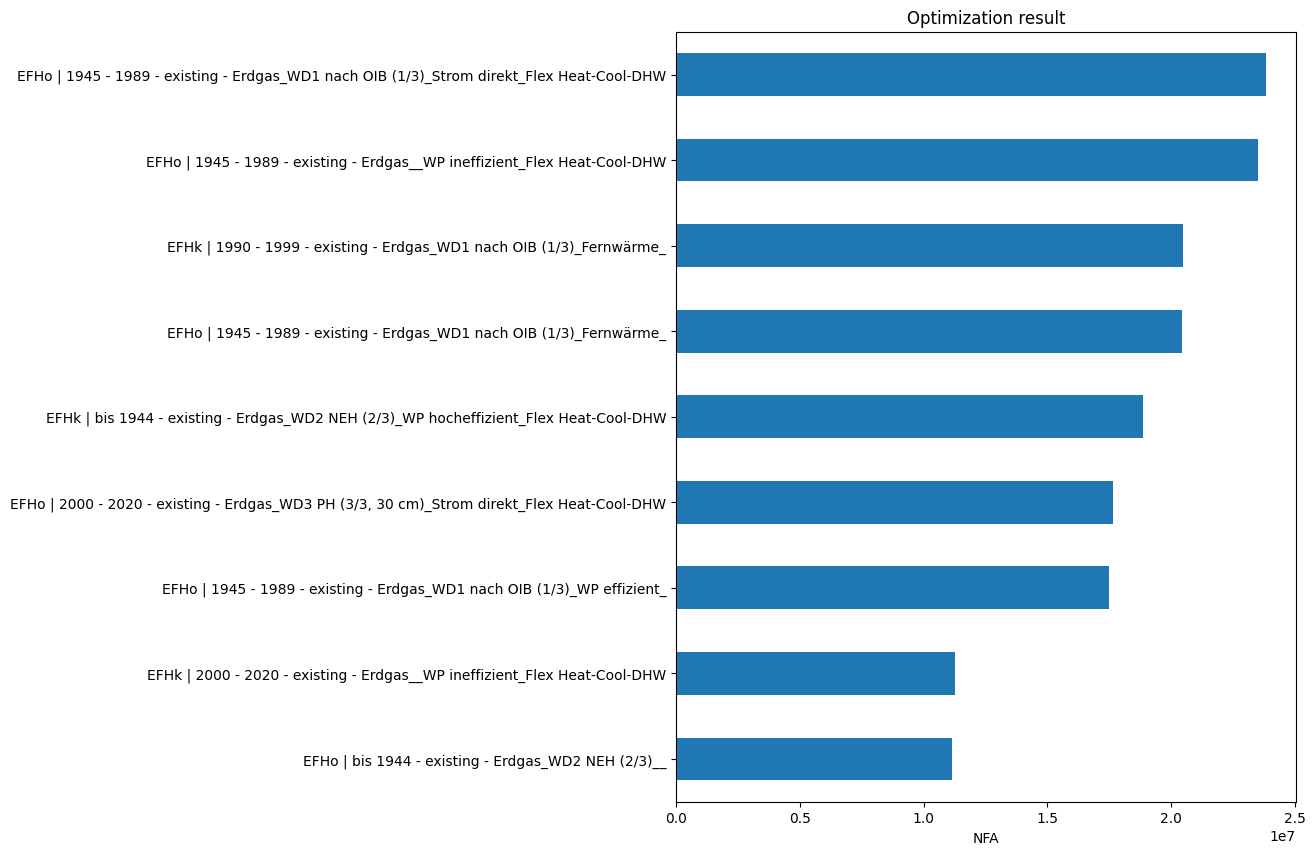

In [18]:
bs.plot_result(
    label_col="Name" if "Name" in result.columns else result.index.name,
    value_col="NFA",
    sort=True,
    figsize=(8, 10),
)
plt.show()

## 13. Inspect slack variables

Slack variables measure how much a soft constraint is violated.

For every constraint, the model creates:

- `s_<constraint>_pos`
- `s_<constraint>_neg`

Large slack values usually indicate inconsistent or impossible constraints, missing archetypes, or wrong target units.

In [19]:
def slack_table(bs):
    rows = []
    for v in bs.model.variables():
        if v.name.startswith("s_"):
            rows.append({
                "slack_variable": v.name,
                "value": v.varValue or 0,
            })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    df["abs_value"] = df["value"].abs()
    return df.sort_values("abs_value", ascending=False)


slacks = slack_table(bs)
display(slacks.head(30))

,slack_variable,value,abs_value
6,s_Stat_AT_48_neg,3.725290e-09,3.725290e-09
0,s_Stat_AT_45_neg,0.000000e+00,0.000000e+00
1,s_Stat_AT_45_pos,0.000000e+00,0.000000e+00
2,s_Stat_AT_46_neg,0.000000e+00,0.000000e+00
4,s_Stat_AT_47_neg,0.000000e+00,0.000000e+00
3,s_Stat_AT_46_pos,0.000000e+00,0.000000e+00
5,s_Stat_AT_47_pos,0.000000e+00,0.000000e+00
7,s_Stat_AT_48_pos,0.000000e+00,0.000000e+00
8,s_Stat_AT_49_neg,0.000000e+00,0.000000e+00
9,s_Stat_AT_49_pos,0.000000e+00,0.000000e+00


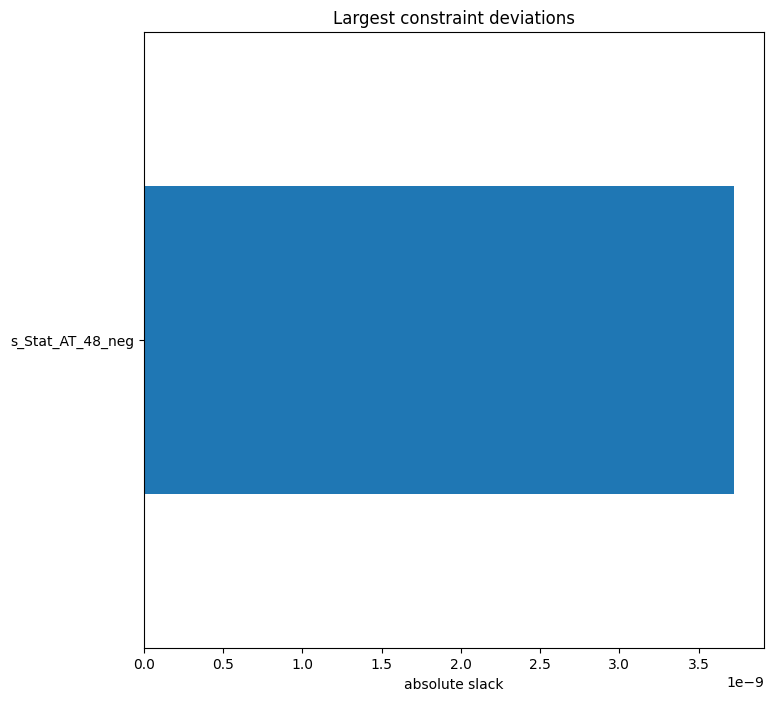

In [20]:
# Plot largest slack values.
top_slacks = slacks[slacks["abs_value"] > 0].head(20)

if not top_slacks.empty:
    ax = top_slacks.set_index("slack_variable")["abs_value"].sort_values().plot(
        kind="barh",
        figsize=(8, 8),
    )
    ax.set_xlabel("absolute slack")
    ax.set_ylabel("")
    ax.set_title("Largest constraint deviations")
    plt.show()
else:
    print("No non-zero slacks.")

## 14. Evaluate constraints after solving

This table recomputes the left-hand side from the solved result and compares it with the target.

For absolute constraints:

\[
lhs = target
\]

For share constraints:

\[
lhs = share \cdot reference
\]

In [21]:
def expression_value_from_result(bs, cfilter, column, result=None, nfa_col="NFA"):
    if result is None:
        result = bs.result_df(value_col=nfa_col)

    ids = bs._filter_indices(cfilter)
    if not ids:
        return 0.0

    if column is None:
        return float(result.loc[ids, nfa_col].sum())

    multiplier = pd.to_numeric(result.loc[ids, column], errors="coerce").fillna(0)
    return float((result.loc[ids, nfa_col] * multiplier).sum())


def evaluate_constraints(bs, nfa_col="NFA"):
    result = bs.result_df(value_col=nfa_col)
    rows = []

    for c in bs.constraints:
        lhs = expression_value_from_result(bs, c.filter, c.column, result, nfa_col)

        if c.type == "absolute":
            rhs = c.target
            reference = np.nan
        elif c.type == "share":
            reference = expression_value_from_result(bs, c.reference_filter, c.column, result, nfa_col)
            rhs = c.target * reference
        else:
            rhs = np.nan
            reference = np.nan

        rows.append({
            "name": c.name,
            "type": c.type,
            "column": c.column,
            "lhs": lhs,
            "target_or_share": c.target,
            "reference": reference,
            "rhs": rhs,
            "deviation": lhs - rhs,
            "abs_deviation": abs(lhs - rhs),
            "filter": c.filter,
            "reference_filter": c.reference_filter,
        })

    return pd.DataFrame(rows).sort_values("abs_deviation", ascending=False)


constraint_eval = evaluate_constraints(bs)
display(constraint_eval.head(30))

,name,type,column,lhs,target_or_share,reference,rhs,deviation,abs_deviation,filter,reference_filter
40,Stat_AT_40,absolute,None,0.0,40679580.0,NaN,40679580.0,-40679580.0,40679580.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
41,Stat_AT_41,absolute,None,0.0,39150298.0,NaN,39150298.0,-39150298.0,39150298.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
36,Stat_AT_36,absolute,None,0.0,37971840.0,NaN,37971840.0,-37971840.0,37971840.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
43,Stat_AT_43,absolute,None,0.0,31511478.0,NaN,31511478.0,-31511478.0,31511478.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
89,Stat_AT_89,absolute,None,0.0,29177200.0,NaN,29177200.0,-29177200.0,29177200.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse...",None
39,Stat_AT_39,absolute,None,0.0,25661130.0,NaN,25661130.0,-25661130.0,25661130.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
44,Stat_AT_44,absolute,None,0.0,23803632.0,NaN,23803632.0,-23803632.0,23803632.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
81,Stat_AT_81,absolute,None,0.0,21282683.0,NaN,21282683.0,-21282683.0,21282683.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse...",None
42,Stat_AT_42,absolute,None,0.0,20714145.0,NaN,20714145.0,-20714145.0,20714145.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
38,Stat_AT_38,absolute,None,0.0,16161055.0,NaN,16161055.0,-16161055.0,16161055.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None


## 15. Basic result indicators

Since `NFA_i` is the decision variable, any specific archetype indicator can be converted to a total by multiplying with NFA.

Example:


$total\_heating = \sum_i NFA_i \cdot heating_i$


In [22]:
def weighted_total(result, specific_col, nfa_col="NFA"):
    # Calculate sum(NFA_i * specific_value_i).
    values = pd.to_numeric(result[specific_col], errors="coerce").fillna(0)
    return float((result[nfa_col] * values).sum())


def total_nfa(result, nfa_col="NFA"):
    return float(result[nfa_col].sum())


print("Total NFA:", total_nfa(result))

Total NFA: 164637040.0


In [23]:
# Calculate totals for all target columns used in the constraints.
target_columns_used = [
    c for c in constraints_df[TARGET_COLUMN_COL].dropna().unique()
    if not is_empty(c) and c in result.columns
]

summary_rows = [{"indicator": "NFA", "target_column": None, "total": total_nfa(result)}]

for col in target_columns_used:
    summary_rows.append({
        "indicator": col,
        "target_column": col,
        "total": weighted_total(result, col),
    })

summary = pd.DataFrame(summary_rows)
display(summary)

,indicator,target_column,total
0,NFA,None,164637040.0


## 16. Aggregate NFA by category

This is the most important sanity check: does the resulting model composition look plausible?

In [24]:
def aggregate_nfa(result, group_col, nfa_col="NFA", min_value=0):
    df = (
        result.groupby(group_col, dropna=False)[nfa_col]
        .sum()
        .sort_values(ascending=False)
        .to_frame("NFA")
    )

    df["share"] = df["NFA"] / df["NFA"].sum()

    if min_value > 0:
        df = df[df["NFA"] > min_value]

    return df


group_col = "Bauperiode (Ebene +2)"

if group_col in result.columns:
    nfa_by_age = aggregate_nfa(result, group_col)
    display(nfa_by_age)
else:
    print(f"Column not found: {group_col}")

,NFA,share
Bauperiode (Ebene +2),,
1971 bis 1980,23839391.0,0.144800
1981 bis 1990,23518958.0,0.142853
1991 bis 2000,20471461.0,0.124343
1961 bis 1970,20440924.0,0.124158
Vor 1919,18855939.0,0.114530
2001 bis 2010,17642541.0,0.107160
1945 bis 1960,17483766.0,0.106196
2011 und später,11250885.0,0.068338
1919 bis 1944,11133175.0,0.067623


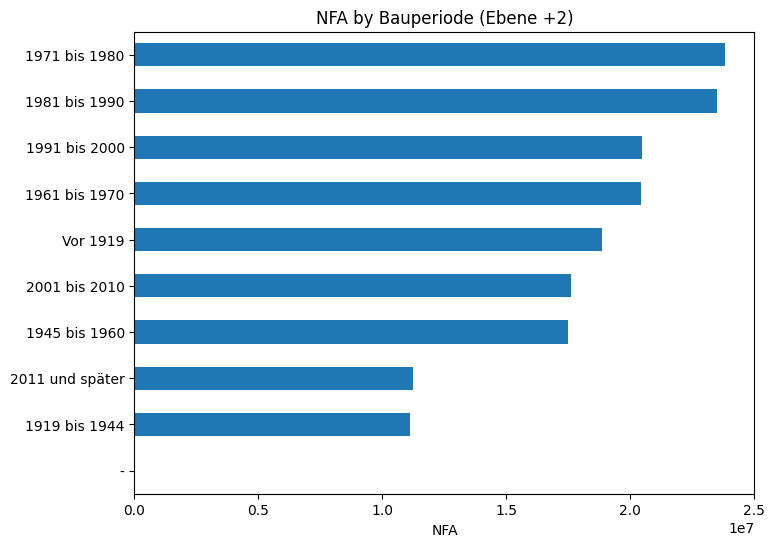

In [25]:
if group_col in result.columns:
    ax = nfa_by_age["NFA"].sort_values().plot(
        kind="barh",
        figsize=(8, 6),
    )
    ax.set_xlabel("NFA")
    ax.set_ylabel("")
    ax.set_title(f"NFA by {group_col}")
    plt.show()

In [26]:
# Try several useful grouping columns.
for col in candidate_category_cols:
    if col in result.columns:
        print(f"\n{col}")
        display(aggregate_nfa(result, col).head(20))


Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)


,NFA,share
Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),,
Wohngebäude,164637040.0,1.0



Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1)


,NFA,share
Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),,
Unter 200 Quadratmeter,164637040.0,1.0
1000 Quadratmeter und mehr,0.0,0.0
300 bis 500 Quadratmeter,0.0,0.0



Bauperiode (Ebene +2)


,NFA,share
Bauperiode (Ebene +2),,
1971 bis 1980,23839391.0,0.144800
1981 bis 1990,23518958.0,0.142853
1991 bis 2000,20471461.0,0.124343
1961 bis 1970,20440924.0,0.124158
Vor 1919,18855939.0,0.114530
2001 bis 2010,17642541.0,0.107160
1945 bis 1960,17483766.0,0.106196
2011 und später,11250885.0,0.068338
1919 bis 1944,11133175.0,0.067623



Building Quality


,NFA,share
Building Quality,,
OIB_1/3,82235542.0,0.499496
original,34769843.0,0.211191
NEH_2/3,29989114.0,0.182153
PH_3/3,17642541.0,0.107160



Geometry


,NFA,share
Geometry,,
EFHo,114058755.0,0.692789
EFHk,50578285.0,0.307211
GWBg,0.0,0.000000
GWBk,0.0,0.000000
MFHk,0.0,0.000000
MFHo,0.0,0.000000


## 17. Aggregate weighted indicators by category

This calculates totals such as energy demand or emissions by category.

Example:


$total\_by\_age = \sum_{i \in age} NFA_i \cdot x_i$


## 18. Two-dimensional distribution tables

Use pivot tables to analyse how the result is distributed across two categories, for example building use and construction period.

In [30]:
def nfa_pivot(result, index_col, column_col, nfa_col="NFA", normalize=False):
    table = pd.pivot_table(
        result,
        values=nfa_col,
        index=index_col,
        columns=column_col,
        aggfunc="sum",
        fill_value=0,
    )

    if normalize:
        total = table.to_numpy().sum()
        if total:
            table = table / total

    return table


row_category = "Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)"
col_category = "Bauperiode (Ebene +2)"

if row_category in result.columns and col_category in result.columns:
    pivot = nfa_pivot(result, row_category, col_category)
    display(pivot)
else:
    print("One of the selected category columns does not exist.")

Bauperiode (Ebene +2),-,1919 bis 1944,1945 bis 1960,1961 bis 1970,1971 bis 1980,1981 bis 1990,1991 bis 2000,2001 bis 2010,2011 und später,Vor 1919
Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),,,,,,,,,,
Wohngebäude,0.0,11133175.0,17483766.0,20440924.0,23839391.0,23518958.0,20471461.0,17642541.0,11250885.0,18855939.0


## 19. Optional: share constraints

A share constraint is useful when a value should be a percentage of a larger total.

Example:

> Gas should be 30% of total residential NFA.

This is linear:

\[
\sum NFA_i[gas] = 0.30 \cdot \sum NFA_i[all]
\]

`model.py` already supports `Constraint(type="share", reference_filter=...)`.

The numerator is selected by `filter`.

The denominator is selected by `reference_filter`.

In [31]:
# Example only. Adjust column and category values to your archetype table.
# This cell does not run if the requested column/value does not exist.

share_col = "EnergySupply"
share_value = "gas"

if share_col in archetype_df.columns and share_value in set(archetype_df[share_col].dropna()):
    bs_share_example = BuildingSector(archetype_df.copy())

    bs_share_example.add_constraint(
        Constraint(
            name="share_gas_global",
            filter={share_col: share_value},  # numerator
            column=None,                      # None = sum NFA
            target=0.30,                      # share
            weight=1_000_000,
            type="share",
            reference_filter=None,            # denominator = all archetypes
        )
    )

    display(bs_share_example.list_constraints())
else:
    print(f"Example skipped: {share_col}={share_value!r} not found.")

Example skipped: EnergySupply='gas' not found.


## 20. Running multiple scenarios

A scenario is simply a different set of constraints.

Typical scenario variations:

- different target year
- different energy supply shares
- different retrofit assumptions
- different CO₂ targets
- different regional subsets

In [33]:
def run_sector_model(
    archetype_df,
    constraints_df,
    filter_cols,
    scenario_name,
    target_col=TARGET_VALUE_COL,
    target_column_col=TARGET_COLUMN_COL,
    weight=1_000_000,
    timeLimit=10,
):
    bs = BuildingSector(archetype_df.copy())

    bs.add_constraints_from_df(
        constraints_df=constraints_df,
        filter_cols=filter_cols,
        target=target_col,
        target_column_col=target_column_col,
        weight=weight,
        name_prefix=scenario_name,
    )

    bs.solve(timeLimit=timeLimit)
    result = bs.result_df(value_col="NFA")

    return bs, result


# Re-run the current scenario through the helper.
bs_base, result_base = run_sector_model(
    archetype_df=archetype_df,
    constraints_df=constraints_df,
    filter_cols=filter_cols,
    scenario_name="base",
    timeLimit=10,
)

Skipping base_0: no matching archetypes
Skipping base_1: no matching archetypes
Skipping base_2: no matching archetypes
Skipping base_3: no matching archetypes
Skipping base_4: no matching archetypes
Skipping base_5: no matching archetypes
Skipping base_6: no matching archetypes
Skipping base_7: no matching archetypes
Skipping base_8: no matching archetypes
Skipping base_9: no matching archetypes
Skipping base_10: no matching archetypes
Skipping base_11: no matching archetypes
Skipping base_12: no matching archetypes
Skipping base_13: no matching archetypes
Skipping base_14: no matching archetypes
Skipping base_15: no matching archetypes
Skipping base_16: no matching archetypes
Skipping base_17: no matching archetypes
Skipping base_18: no matching archetypes
Skipping base_19: no matching archetypes
Skipping base_20: no matching archetypes
Skipping base_21: no matching archetypes
Skipping base_22: no matching archetypes
Skipping base_23: no matching archetypes
Skipping base_24: no match

In [34]:
def scenario_summary(result, scenario_name, indicator_cols=None, nfa_col="NFA"):
    rows = [{
        "scenario": scenario_name,
        "indicator": "NFA",
        "total": total_nfa(result, nfa_col=nfa_col),
    }]

    if indicator_cols is None:
        indicator_cols = []

    for col in indicator_cols:
        if col in result.columns:
            rows.append({
                "scenario": scenario_name,
                "indicator": col,
                "total": weighted_total(result, col, nfa_col=nfa_col),
            })

    return pd.DataFrame(rows)


indicator_cols = target_columns_used[:5]
scenario_summary(result_base, "base", indicator_cols=indicator_cols)

,scenario,indicator,total
0,base,NFA,164637040.0


## 21. Compare scenarios from different Excel sheets

If your constraints workbook contains several sheets, you can loop over them.

Adjust `scenario_sheets` to your workbook.

In [35]:
# Example only. Add more sheet names if they exist in your workbook.
scenario_sheets = [CONSTRAINT_SHEET]

scenario_results = {}
scenario_summaries = []

for sheet in scenario_sheets:
    cdf = pd.read_excel(CONSTRAINTS_PATH, sheet_name=sheet)

    if TARGET_VALUE_COL not in cdf.columns and "Anzahl NGF m²" in cdf.columns:
        cdf = cdf.rename(columns={"Anzahl NGF m²": TARGET_VALUE_COL})

    if TARGET_COLUMN_COL not in cdf.columns:
        cdf[TARGET_COLUMN_COL] = np.nan

    if REGION_COL in cdf.columns:
        cdf = cdf[cdf[REGION_COL].eq(REGION_VALUE)].copy()

    bs_s, result_s = run_sector_model(
        archetype_df=archetype_df,
        constraints_df=cdf,
        filter_cols=filter_cols,
        scenario_name=sheet,
        timeLimit=10,
    )

    scenario_results[sheet] = result_s
    scenario_summaries.append(
        scenario_summary(result_s, sheet, indicator_cols=indicator_cols)
    )

comparison = pd.concat(scenario_summaries, ignore_index=True)
display(comparison)

Skipping NGF_0: no matching archetypes
Skipping NGF_1: no matching archetypes
Skipping NGF_2: no matching archetypes
Skipping NGF_3: no matching archetypes
Skipping NGF_4: no matching archetypes
Skipping NGF_5: no matching archetypes
Skipping NGF_6: no matching archetypes
Skipping NGF_7: no matching archetypes
Skipping NGF_8: no matching archetypes
Skipping NGF_9: no matching archetypes
Skipping NGF_10: no matching archetypes
Skipping NGF_11: no matching archetypes
Skipping NGF_12: no matching archetypes
Skipping NGF_13: no matching archetypes
Skipping NGF_14: no matching archetypes
Skipping NGF_15: no matching archetypes
Skipping NGF_16: no matching archetypes
Skipping NGF_17: no matching archetypes
Skipping NGF_18: no matching archetypes
Skipping NGF_19: no matching archetypes
Skipping NGF_20: no matching archetypes
Skipping NGF_21: no matching archetypes
Skipping NGF_22: no matching archetypes
Skipping NGF_23: no matching archetypes
Skipping NGF_24: no matching archetypes
Skipping N

,scenario,indicator,total
0,NGF,NFA,164637040.0


In [36]:
if not comparison.empty:
    comparison_pivot = comparison.pivot(
        index="indicator",
        columns="scenario",
        values="total",
    )
    display(comparison_pivot)

scenario,NGF
indicator,
NFA,164637040.0


## 22. Export results

Export the solved archetype table, constraint evaluation, and summary indicators to Excel.

In [37]:
OUTPUT_DIR = Path("../results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = OUTPUT_DIR / "building_sector_model_results.xlsx"

with pd.ExcelWriter(OUTPUT_PATH) as writer:
    result.to_excel(writer, sheet_name="result_archetypes")
    constraint_eval.to_excel(writer, sheet_name="constraint_eval", index=False)
    slacks.to_excel(writer, sheet_name="slacks", index=False)
    summary.to_excel(writer, sheet_name="summary", index=False)

print("Wrote:", OUTPUT_PATH.resolve())

Wrote: C:\Users\schneids\code\building-archetype-inference\results\building_sector_model_results.xlsx


## 23. Practical workflow for assignments

Recommended student workflow:

1. Open the constraints workbook.
2. Add or modify rows.
3. Keep filter columns clear and consistent with the archetype table.
4. Use empty filter cells when a constraint should apply to all categories of that column.
5. Use empty `target_column` for total NFA constraints.
6. Use a specific `target_column` for weighted totals such as energy or emissions.
7. Run validation before solving.
8. Check slacks and constraint deviations.
9. Analyse NFA, energy, and CO₂ distributions.
10. Export the result tables and use plots in the report.

Key interpretation rule:

A result is not just “the model solved”. A result is useful only if:

- the constraints are traceable,
- slacks are small or explainable,
- category distributions are plausible,
- units of target columns and target values match,
- the scenario assumptions are documented.

## 24. Useful short snippets

Copy these into new cells when exploring results.

In [38]:
# Total NFA
result["NFA"].sum()

np.float64(164637040.0)

In [39]:
# Top 20 archetypes by NFA
result.sort_values("NFA", ascending=False).head(20)

,Total Net floor Area,Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2),Geometry,m²NGF,Nettogrundfläche in Quadratmetern (in Klassen) (Ebene +1),Building Period,Bauperiode (Ebene +2),Building Quality,renovated,thermisch wirksame Speichermasse,Energy Supply,Type of Heat Pump,Flexibility,Name,Projektname__,Adresse__,Erstellungsdatum__,Variante / Scenario__,GFZ__,Sanierungsanteil__,Raumhöhe __m Netto,Charakteristische Länge (lc)__m,Wetterdatensatz Name__,Wetterdatensatz Nummer__,Außentemperatur Jahresmittel__°C,Mittelaußentemperatur Heizperiode__°C,Mittelaußentemperatur Kühlperiode__°C,Nutzungsmischung__,Nutzerstrom_Quartier_kWh/m²NGFa,Beleuchtung_Quartier_kWh/m²NGFa,Allgemeinstrom_Quartier_kWh/m²NGFa,Heiwärmebedarf_Quartier_kWh/m²NGFa,Külenergiebedarf_Quartier_kWh/m²NGFa,WWWB_Quartier_kWh/m²NGFa,Lüftungsenergiebedarf_Quartier_kWh/m²NGFa,E-Mobilität_Quartier_kWh/m²NGFa,Fossile Mobilität_Quartier_kWh/m²NGFa,__,Transmissionswärmeverl._Quartier_kWh/m²NGFa,Lüftungswärmeverluste_Quartier_kWh/m²NGFa,Nachtlüftung_Quartier_kWh/m²NGFa,Solare Gewinne_Quartier_kWh/m²NGFa,Innere Wärmen_Quartier_kWh/m²NGFa,Heizwärmebedarf_Quartier_kWh/m²NGFa,Kühlbedarf (KB)_Quartier_kWh/m²NGFa,ML Wärmerückgewinnung_Quartier_kWh/m²NGFa,#BEZUG!,Transmissionswärmeverl._Heizperiode_kWh/m²NGFa,Lüftungswärmeverluste_Heizperiode_kWh/m²NGFa,Nachtlüftung_Heizperiode_kWh/m²NGFa,Solare Gewinne_Heizperiode_kWh/m²NGFa,Innere Wärmen_Heizperiode_kWh/m²NGFa,Heizwärmebedarf_Heizperiode_kWh/m²NGFa,Kühlbedarf (KB)_Heizperiode_kWh/m²NGFa,#BEZUG!2,Transmission AW_Heizperiode_kWh/m²NGFa,Transmission Dach_Heizperiode_kWh/m²NGFa,Transmission KD/EFB_Heizperiode_kWh/m²NGFa,Transmission Fenster_Heizperiode_kWh/m²NGFa,Transmission Wärmebrücken_Heizperiode_kWh/m²NGFa,...,Jährliche Entladung__kWh/m²NGFa,Verluste Beladung__kWh/m²NGFa,Verluste Entladung__kWh/m²NGFa,Round-Trip- Efficiency__,Batterie Volladezyklen__x,__67,__68,Wohnbau__StatPAX,Arbeit__StatPAX,Büro und Gewerbe__StatPAX,"Bildundseinrichtungen (Kindergarten, Primär)__StatPAX","Bildungseinrichtung (sekundär, Tertiär)__StatPAX",Einkaufen__StatPAX,Lebensmittelhandel (Supermarkt)__StatPAX,Handel Sonstige__StatPAX,Quartier__StatPAX,Wohnen__km/a,Arbeit__km/a,"Bildungseinrichtung (sekundär, Tertiär)__km/a",Handel__km/a,Gesamtverkehr__km/a,Gesamtverkehr pro STATPAX__km/PAX/a,Zielverkehr zum Quartier__km/a,Zielverkehr Elektrisch__km/a,Zielverkehr Fossil__km/a,Zielverkehr zum Quartier pro Person__km/PAX/a,Zielverkehrsanteil__,__69,Quell- und anderer Verkehr__km/a,Alle Wege__km/a,EE-Bedarf Zielverkehr Elektrisch__kWh/m²NGFa,EE-Bedarf Zielverkehr Fossil__kWh/m²NGFa,__70,Anzahl E-Cars__,Batterie-Kapazität__Wh/m²,EV Volladezyklen__,Gesamtverkehr elektrisch__kWh/m²NGFa,Quell- und anderer Verkehr elektrisch__kWh/m²NGFa,__71,EV Jährliche Beladung__,EV Jährliche Entladung__,EV Verluste__,EV Verluste Beladung__,__72,Hilfssstrom Heizen__kWh/m²NGFa,Hilfsstrom Kühlen__kWh/m²NGFa,Hilfsstrom Warmwasser__kWh/m²NGFa,__73,WW-Wärmebedarf__kWh/m²NGFa,WW Endenergiebedarf Thermisch__kWh/m²NGFa,WW Endenergiebedarf Elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW Hilfsstrom__,WW 1 Endenergie thermisch__kWh/m²NGFa,WW 1 Endenergie elektrisch (inkl. Hilfsstrom)__kWh/m²NGFa,WW 1 Hilfsstrom__kWh/m²NGFa,WW 2 Endenergie thermisch__kWh/m²NGFa,WW 2 Endenergie elektrisch (inkl.Hilfsstrom)__kWh/m²NGFa,WW 2 Hilfsstrom__kWh/m²NGFa,buildings,NFA
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2058,NaN,Wohngebäude,EFHo,137.184,Unter 200 Quadratmeter,1945 - 1989,1971 bis 1980,OIB_1/3,1,mittel (124 Wh/m²K),Electricity (direct),NaN,1,EFHo | 1945 - 1989 - existing - Erdgas_WD1 nach OIB (1/3)_Strom direkt_Flex Heat-Cool-DHW,EFHo,Keine Daten,46037,1945 - 1989 - existing - Erdgas,0.244971,0,2.65,0.821953,Salzburg,9,9.932626,5.653857,NaN,"100% Wohnen, 0% Büro und Gewerbe, 0% Bildungseinrichtung (sekundär, Tertiär), 0% Kindergarten und Volksschule, 0% Le...",26.687184,0,1.752,99.193328,0.000000,15.975,1.999543,0

In [40]:
# NFA share by category
aggregate_nfa(result, "Bauperiode (Ebene +2)").assign(share_percent=lambda df: 100 * df["share"])

,NFA,share,share_percent
Bauperiode (Ebene +2),,,
1971 bis 1980,23839391.0,0.144800,14.479968
1981 bis 1990,23518958.0,0.142853,14.285338
1991 bis 2000,20471461.0,0.124343,12.434299
1961 bis 1970,20440924.0,0.124158,12.415750
Vor 1919,18855939.0,0.114530,11.453036
2001 bis 2010,17642541.0,0.107160,10.716022
1945 bis 1960,17483766.0,0.106196,10.619582
2011 und später,11250885.0,0.068338,6.833751
1919 bis 1944,11133175.0,0.067623,6.762254


In [41]:
# Weighted total of one indicator
# Replace indicator_col with any column in archetype_df that is specific per m² NFA.
weighted_total(result, indicator_col)

18358442644.401222

In [42]:
# Find columns by keyword
keyword = "CO2"
[c for c in result.columns if keyword.lower() in c.lower()]

['Bauteil Außenwand fossil__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Außenwand biogen__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Außenwand__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Fenster fossil__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Fenster biogen__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Fenster __GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Dach fossil__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Dach biogen__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Dach__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Decke gegen Erdreich / Keller fossil__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Decke gegen Erdreich / Keller biogen__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Decke gegen Erdreich / Keller__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Zwischengeschoßdecken fossil__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Zwischengeschoßdecken biogen__GWP 100A (kgCO2equiv/m²BGF)',
 'Bauteil Zwischengeschoßdecken__GWP 100A (kgCO2equiv/m²BGF)',
 'Baulich Allgemein fossil__GWP 100A (kgCO2equiv/m²BGF)',
 'Baulich Allgemein biogen__GWP

In [43]:
# Check constraints with largest deviations
evaluate_constraints(bs).head(20)

,name,type,column,lhs,target_or_share,reference,rhs,deviation,abs_deviation,filter,reference_filter
40,Stat_AT_40,absolute,None,0.0,40679580.0,NaN,40679580.0,-40679580.0,40679580.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
41,Stat_AT_41,absolute,None,0.0,39150298.0,NaN,39150298.0,-39150298.0,39150298.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
36,Stat_AT_36,absolute,None,0.0,37971840.0,NaN,37971840.0,-37971840.0,37971840.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
43,Stat_AT_43,absolute,None,0.0,31511478.0,NaN,31511478.0,-31511478.0,31511478.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
89,Stat_AT_89,absolute,None,0.0,29177200.0,NaN,29177200.0,-29177200.0,29177200.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse...",None
39,Stat_AT_39,absolute,None,0.0,25661130.0,NaN,25661130.0,-25661130.0,25661130.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
44,Stat_AT_44,absolute,None,0.0,23803632.0,NaN,23803632.0,-23803632.0,23803632.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
81,Stat_AT_81,absolute,None,0.0,21282683.0,NaN,21282683.0,-21282683.0,21282683.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Wohngebäude', 'Nettogrundfläche in Quadratmetern (in Klasse...",None
42,Stat_AT_42,absolute,None,0.0,20714145.0,NaN,20714145.0,-20714145.0,20714145.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None
38,Stat_AT_38,absolute,None,0.0,16161055.0,NaN,16161055.0,-16161055.0,16161055.0,"{'Gebäudeigenschaft (überwiegende Nutzung) (Ebene +2)': 'Andere Gebäude', 'Nettogrundfläche in Quadratmetern (in Kla...",None


In [44]:
# Remove and rebuild constraints during development
bs.clear_constraints()
bs.add_constraints_from_df(
    constraints_df=constraints_df,
    filter_cols=filter_cols,
    target=TARGET_VALUE_COL,
    target_column_col=TARGET_COLUMN_COL,
    weight=1_000_000,
    name_prefix="Stat_AT",
)
bs.solve(timeLimit=10)

Skipping Stat_AT_0: no matching archetypes
Skipping Stat_AT_1: no matching archetypes
Skipping Stat_AT_2: no matching archetypes
Skipping Stat_AT_3: no matching archetypes
Skipping Stat_AT_4: no matching archetypes
Skipping Stat_AT_5: no matching archetypes
Skipping Stat_AT_6: no matching archetypes
Skipping Stat_AT_7: no matching archetypes
Skipping Stat_AT_8: no matching archetypes
Skipping Stat_AT_9: no matching archetypes
Skipping Stat_AT_10: no matching archetypes
Skipping Stat_AT_11: no matching archetypes
Skipping Stat_AT_12: no matching archetypes
Skipping Stat_AT_13: no matching archetypes
Skipping Stat_AT_14: no matching archetypes
Skipping Stat_AT_15: no matching archetypes
Skipping Stat_AT_16: no matching archetypes
Skipping Stat_AT_17: no matching archetypes
Skipping Stat_AT_18: no matching archetypes
Skipping Stat_AT_19: no matching archetypes
Skipping Stat_AT_20: no matching archetypes
Skipping Stat_AT_21: no matching archetypes
Skipping Stat_AT_22: no matching archetype

1       0.0
2       0.0
3       0.0
4       0.0
5       0.0
       ... 
2876    NaN
2877    NaN
2878    NaN
2879    NaN
2880    NaN
Length: 2880, dtype: float64

## 25. Assignment ideas

Possible analyses:

- Compare scenarios with different energy supply assumptions.
- Analyse whether building age or building quality dominates heating demand.
- Compare CO₂ emissions by construction period.
- Create a retrofit scenario and compare energy/emission reductions.
- Analyse how sensitive results are to broad constraints versus detailed constraints.
- Identify which constraints are difficult to satisfy and explain why.
- Use share constraints to control technology mixes, for example gas, district heating, heat pumps, or biomass.